# Теоретическая справка: Propensity Score

## Что такое Propensity Score?

Propensity Score (вероятностная оценка склонности) — это вероятность того, что объект (например, человек, пациент или клиент) получит определенное воздействие (лечение, программа, интервенция) с учетом набора наблюдаемых характеристик (ковариат). Концепт был предложен Розенбаумом и Рубином в 1983 году для снижения смещения в наблюдательных исследованиях, где рандомизация невозможна. PSM позволяет сбалансировать ковариаты между группами лечения и контроля, имитируя условия рандомизированного контролируемого испытания (РКИ).

## Основные понятия

- **Причинно-следственный вывод (Causal Inference)**: PSM используется для оценки причинного эффекта воздействия (например, программы обучения на доходы или лечения на здоровье) в наблюдательных данных.
- **Ковариаты**: Переменные, которые могут влиять на выбор лечения и исход (например, возраст, пол, доход). Их несбалансированность может привести к смещению.
- **Балансировка**: PSM уравнивает распределение ковариат между группами лечения и контроля, минимизируя влияние конфундеров.
- **Методы соответствия**: Наиболее распространены парное соответствие (nearest neighbor matching), соответствие с калипером и стратификация по вероятностным оценкам.

## Ключевые предположения

1. **Условная независимость (Conditional Independence)**: При заданной вероятностной оценке потенциальные исходы независимы от назначения лечения.
2. **Общая поддержка (Common Support)**: Для каждого значения вероятностной оценки должны существовать как обработанные, так и контрольные объекты, чтобы обеспечить сравнимость.

## Этапы PSM

1. **Оценка вероятностных оценок**: Используется модель (обычно логистическая регрессия) для предсказания вероятности получения лечения на основе ковариат.
2. **Соответствие (Matching)**: Объекты из группы лечения и контроля подбираются так, чтобы их вероятностные оценки были близки.
3. **Проверка баланса**: Проверяется, насколько хорошо сбалансированы ковариаты после соответствия (например, с помощью стандартизированной разницы средних, SMD).
4. **Оценка эффекта лечения**: Рассчитывается эффект, например, средний эффект лечения на обработанных (ATT) или средний эффект лечения (ATE).
5. **Анализ чувствительности**: Оценивается устойчивость результатов к возможным скрытым конфундерам.

## Применение

PSM широко используется в эпидемиологии, экономике и социальных науках для оценки эффектов интервенций, таких как:

- Влияние образовательных программ на доход.
- Эффективность медицинских процедур на здоровье.
- Воздействие маркетинговых кампаний на поведение потребителей.

## Ограничения

- PSM учитывает только наблюдаемые ковариаты. Скрытые конфундеры могут искажать результаты.
- Требуется достаточное перекрытие вероятностных оценок (общая поддержка).
- Результаты зависят от выбора метода соответствия и спецификации модели.

## Литература

- Розенбаум, П., & Рубин, Д. (1983). "The central role of the propensity score in observational studies for causal effects." *Biometrika*.
- Пёрл, Дж., Глаймур, М., & Джуэлл, Н. (2016). *Причинно-следственный вывод в статистике: Введение*. Wiley.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Step 1: Load and preprocess the Lalonde dataset
url = "https://vincentarelbundock.github.io/Rdatasets/csv/MatchIt/lalonde.csv"
df = pd.read_csv(url)
df

,rownames,treat,age,educ,race,married,nodegree,re74,re75,re78
0,NSW1,1,37,11,black,1,1,0.0,0.0,9930.0460
1,NSW2,1,22,9,hispan,0,1,0.0,0.0,3595.8940
2,NSW3,1,30,12,black,0,0,0.0,0.0,24909.4500
3,NSW4,1,27,11,black,0,1,0.0,0.0,7506.1460
4,NSW5,1,33,8,black,0,1,0.0,0.0,289.7899
...,...,...,...,...,...,...,...,...,...,...
609,PSID425,0,18,11,white,0,1,0.0,0.0,10150.5000
610,PSID426,0,24,1,hispan,1,1,0.0,0.0,19464.6100
611,PSID427,0,21,18,white,0,0,0.0,0.0,0.0000
612,PSID428,0,32,5,black,1,1,0.0,0.0,187.6713


In [2]:
race_ohe = pd.get_dummies(df['race'], prefix='race')
race_ohe

,race_black,race_hispan,race_white
0,True,False,False
1,False,True,False
2,True,False,False
3,True,False,False
4,True,False,False
...,...,...,...
609,False,False,True
610,False,True,False
611,False,False,True
612,True,False,False


In [4]:
# df = pd.concat([df, race_ohe], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rownames     614 non-null    object 
 1   treat        614 non-null    int64  
 2   age          614 non-null    int64  
 3   educ         614 non-null    int64  
 4   race         614 non-null    object 
 5   married      614 non-null    int64  
 6   nodegree     614 non-null    int64  
 7   re74         614 non-null    float64
 8   re75         614 non-null    float64
 9   re78         614 non-null    float64
 10  race_black   614 non-null    bool   
 11  race_hispan  614 non-null    bool   
 12  race_white   614 non-null    bool   
dtypes: bool(3), float64(3), int64(5), object(2)
memory usage: 49.9+ KB


In [5]:
# Выбор ковариат
covariates = ['age', 'educ', 'race_black', 'race_hispan', 'race_white',
              'married', 'nodegree', 're74', 're75']
X = df[covariates].copy()
y = df['treat'].copy()
outcome = df['re78']
ids = df['rownames']

# Стандартизация непрерывных ковариат
scaler = StandardScaler()
X[['age', 'educ', 're74', 're75']] = scaler.fit_transform(X[['age', 'educ', 're74', 're75']])
X

,age,educ,race_black,race_hispan,race_white,married,nodegree,re74,re75
0,0.976063,0.278454,True,False,False,1,1,-0.70412,-0.663511
1,-0.543211,-0.483108,False,True,False,0,1,-0.70412,-0.663511
2,0.267069,0.659234,True,False,False,0,0,-0.70412,-0.663511
3,-0.036786,0.278454,True,False,False,0,1,-0.70412,-0.663511
4,0.570924,-0.863888,True,False,False,0,1,-0.70412,-0.663511
...,...,...,...,...,...,...,...,...,...
609,-0.948350,0.278454,False,False,True,0,1,-0.70412,-0.663511
610,-0.340641,-3.529353,False,True,False,1,1,-0.70412,-0.663511
611,-0.644495,2.943919,False,False,True,0,0,-0.70412,-0.663511
612,0.469639,-2.006231,True,False,False,1,1,-0.70412,-0.663511


In [20]:
log_reg.predict_proba(X)

array([[0.37216218, 0.62783782],
       [0.77087595, 0.22912405],
       [0.3264775 , 0.6735225 ],
       ...,
       [0.8151161 , 0.1848839 ],
       [0.60355352, 0.39644648],
       [0.90379263, 0.09620737]])

<Axes: >

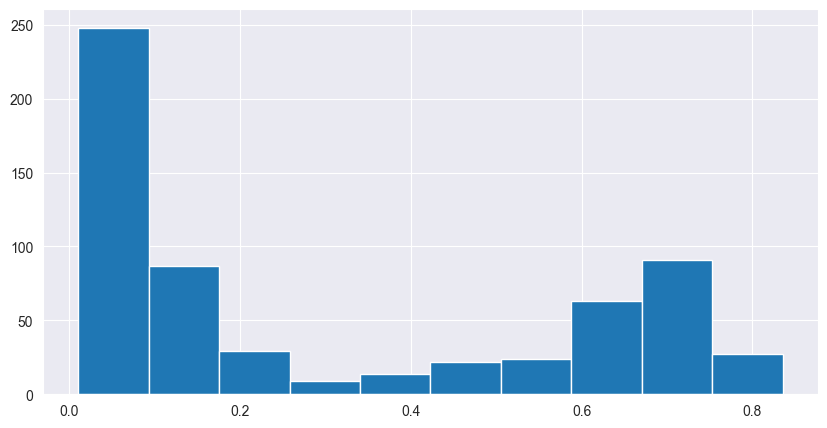

In [9]:
# Шаг 2: Оценка propensity score
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X, y)
propensity_scores = log_reg.predict_proba(X)[:, 1]  # Вероятность лечения (P(treat=1))

# Добавление propensity score в датасет
df['propensity_score'] = propensity_scores
df['propensity_score'].hist(figsize = (10,5))

In [14]:
# Шаг 3: 1:1 Nearest Neighbor Matching без замены с калипером
def nearest_neighbor_matching(df, caliper=0.1):
    treated = df.loc[df['treat'] == 1, ['rownames', 'propensity_score', 're78']]
    control = df.loc[df['treat'] == 0, ['rownames', 'propensity_score', 're78']]
    matched_pairs = []

    # # Для каждого обработанного объекта ищем ближайший контроль
    # for t_id, t_ps in treated[['rownames', 'propensity_score']].values:
    #     c_idx = np.argmin(np.abs(control['propensity_score'] - t_ps))
    #     if np.abs(control.iloc[c_idx]['propensity_score'] - t_ps) > caliper:
    #         continue
    #     c_id = control.iloc[c_idx]['rownames']
    #     matched_pairs.append((t_id, c_id))
    #     control = control[control['rownames'] != t_id]

    for t_id, t_ps in treated[['rownames', 'propensity_score']].values:
        # Фильтр контроля по калиперу
        control_subset = control[np.abs(control['propensity_score'] - t_ps) <= caliper]
        if len(control_subset) == 0:
            continue  # Пропускаем, если нет подходящих пар
        # Находим ближайший контроль
        c_idx = np.argmin(np.abs(control_subset['propensity_score'] - t_ps))
        c_id = control_subset.iloc[c_idx]['rownames']
        matched_pairs.append((t_id, c_id))
        # Удаляем использованный контроль
        control = control[control['rownames'] != c_id]

    # Создаем датасет с парами
    matched_ids = [t_id for t_id, _ in matched_pairs] + [c_id for _, c_id in matched_pairs]
    matched_df = df[df['rownames'].isin(matched_ids)].copy()
    return matched_df, len(matched_pairs)

matched_df, num_matches = nearest_neighbor_matching(df)
print(f"Количество пар соответствия: {num_matches}")

Количество пар соответствия: 114


In [15]:
# Шаг 4: Проверка баланса ковариат
def calculate_smd(df, covariates, group_col='treat'):
    smd_results = []
    for cov in covariates:
        treated_vals = df[df[group_col] == 1][cov]
        control_vals = df[df[group_col] == 0][cov]
        mean_diff = treated_vals.mean() - control_vals.mean()
        pooled_std = np.sqrt((treated_vals.var() + control_vals.var()) / 2)
        smd = mean_diff / pooled_std if pooled_std != 0 else 0
        smd_results.append(smd)
    return pd.DataFrame({'covariate': covariates, 'SMD': smd_results})

# SMD до и после соответствия
smd_before = calculate_smd(df, covariates)
smd_after = calculate_smd(matched_df, covariates)
print("\nSMD до соответствия:\n", smd_before)
print("\nSMD после соответствия:\n", smd_after)


SMD до соответствия:
      covariate       SMD
0          age -0.241904
1         educ  0.044755
2   race_black  1.667719
3  race_hispan -0.276940
4   race_white -1.405738
5      married -0.719492
6     nodegree  0.235048
7         re74 -0.595752
8         re75 -0.287002

SMD после соответствия:
      covariate       SMD
0          age  0.032363
1         educ  0.007191
2   race_black  0.019942
3  race_hispan  0.030205
4   race_white -0.046881
5      married -0.041093
6     nodegree -0.036605
7         re74 -0.118016
8         re75 -0.333145


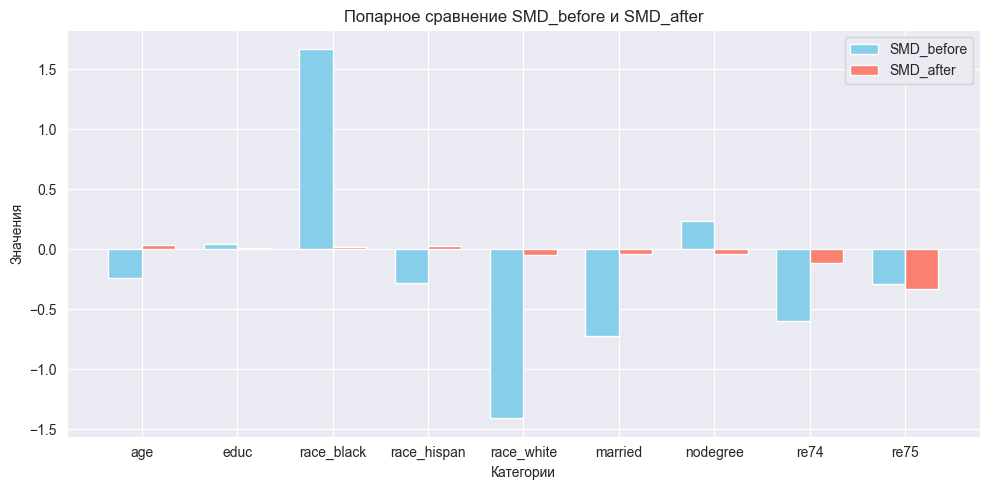

In [19]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(10,5))
bar_width = 0.35
x = np.arange(len(covariates))
# Рисуем столбцы для каждой группы
bar1 = ax.bar(x - bar_width/2, smd_before["SMD"].values, bar_width, label='SMD_before', color='skyblue')
bar2 = ax.bar(x + bar_width/2, smd_after["SMD"].values, bar_width, label='SMD_after', color='salmon')

# Настройки графика
ax.set_xlabel('Категории')
ax.set_ylabel('Значения')
ax.set_title('Попарное сравнение SMD_before и SMD_after')
ax.set_xticks(x)
ax.set_xticklabels(covariates)
ax.legend()

# # Добавляем подписи значений над столбцами
# def add_labels(bars):
#     for bar in bars:
#         height = bar.get_height()
#         ax.annotate(f'{height}',
#                     xy=(bar.get_x() + bar.get_width() / 2, height),
#                     xytext=(0, 3),  # Смещение по вертикали
#                     textcoords="offset points",
#                     ha='center', va='bottom')

# add_labels(bar1)
# add_labels(bar2)

plt.tight_layout()
plt.show()

In [21]:
# Шаг 5: Оценка эффекта лечения (ATT)
att = matched_df[matched_df['treat'] == 1]['re78'].mean() - matched_df[matched_df['treat'] == 0]['re78'].mean()
print(f"\nОцененный ATT: {att:.2f} (разница в среднем доходе в 1978 году)")


Оцененный ATT: 856.19 (разница в среднем доходе в 1978 году)


In [22]:
# Для сравнения оценка эффекта без PSM, показывает диаметрально противоположный результат
att = df[df['treat'] == 1]['re78'].mean() - df[df['treat'] == 0]['re78'].mean()
print(f"\nОцененный ATT: {att:.2f} (разница в среднем доходе в 1978 году)")


Оцененный ATT: -635.03 (разница в среднем доходе в 1978 году)


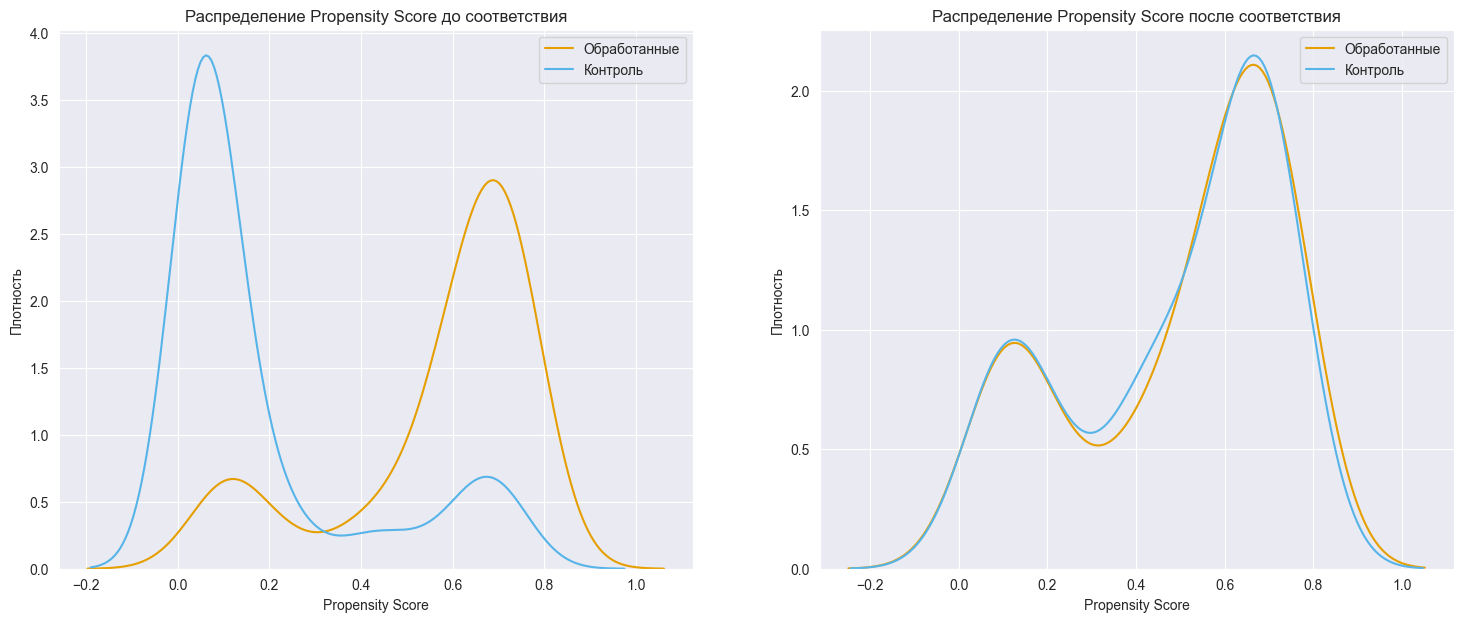

In [36]:
# Шаг 6: Визуализация
# Распределение propensity score
fig, axes = plt.subplots(figsize=(18,7), nrows=1, ncols=2)

ax = axes[0]
sns.kdeplot(data=df[df['treat'] == 1], x='propensity_score', label='Обработанные', color='#E69F00', ax=ax)
sns.kdeplot(data=df[df['treat'] == 0], x='propensity_score', label='Контроль', color='#56B4E9', ax=ax)
ax.set_title('Распределение Propensity Score до соответствия')
ax.set_xlabel('Propensity Score')
ax.set_ylabel('Плотность')
ax.legend()

# Распределение propensity score
ax = axes[1]
sns.kdeplot(data=matched_df[matched_df['treat'] == 1], x='propensity_score', label='Обработанные', color='#E69F00', ax=ax)
sns.kdeplot(data=matched_df[matched_df['treat'] == 0], x='propensity_score', label='Контроль', color='#56B4E9', ax=ax)
ax.set_title('Распределение Propensity Score после соответствия')
ax.set_xlabel('Propensity Score')
ax.set_ylabel('Плотность')
ax.legend()

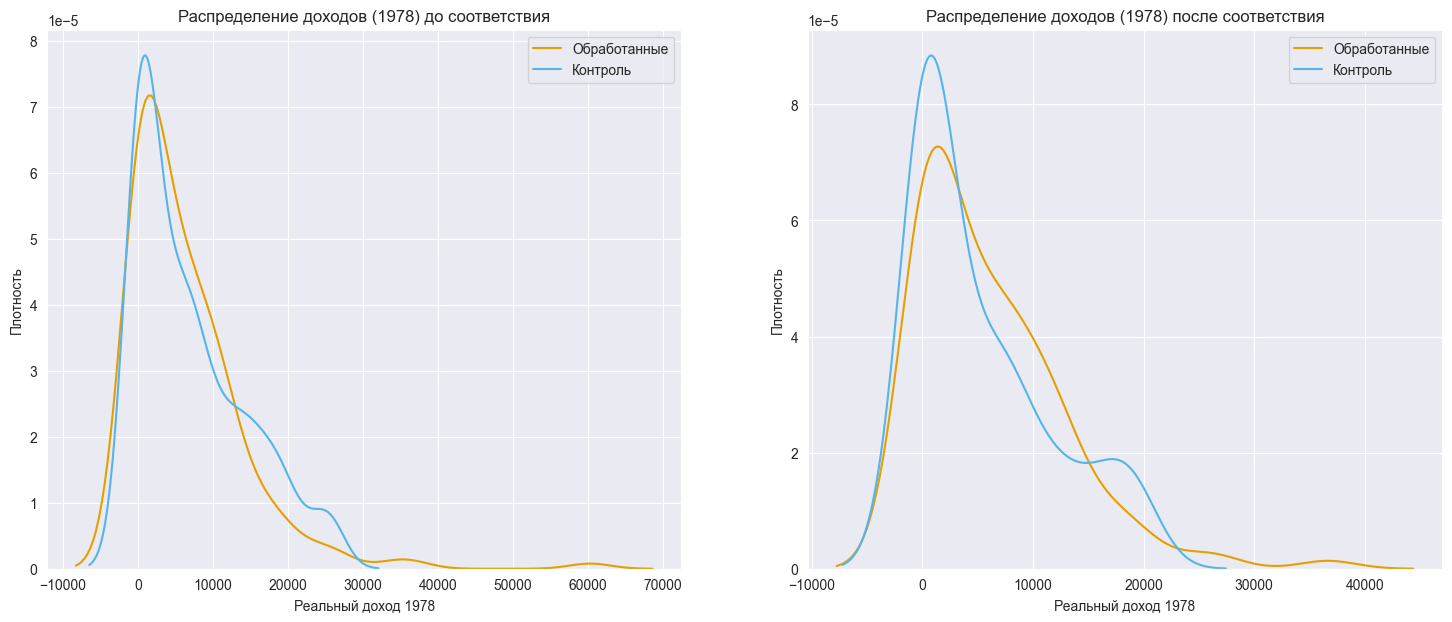

In [39]:
fig, axes = plt.subplots(figsize=(18,7), nrows=1, ncols=2)

# Распределение доходов после соответствия
ax = axes[0]
sns.kdeplot(data=df[df['treat'] == 1], x='re78', label='Обработанные', color='#E69F00', ax=ax)
sns.kdeplot(data=df[df['treat'] == 0], x='re78', label='Контроль', color='#56B4E9', ax=ax)
ax.set_title('Распределение доходов (1978) до соответствия')
ax.set_xlabel('Реальный доход 1978')
ax.set_ylabel('Плотность')
ax.legend()


ax = axes[1]
sns.kdeplot(data=matched_df[matched_df['treat'] == 1], x='re78', label='Обработанные', color='#E69F00', ax=ax)
sns.kdeplot(data=matched_df[matched_df['treat'] == 0], x='re78', label='Контроль', color='#56B4E9', ax=ax)
ax.set_title('Распределение доходов (1978) после соответствия')
ax.set_xlabel('Реальный доход 1978')
ax.set_ylabel('Плотность')
ax.legend()